# Mutual Fund Analytics — Advanced Analytics + Risk Metrics

**Ticket:** Advanced Analytics + Risk Metrics
**Deliverables:** `Advanced_Analytics.ipynb`, `var_cvar_report.csv`, `recommender.py` (separate file), `rolling_sharpe_chart.png`.

Reads from `data/processed/`. Covers Historical VaR/CVaR, rolling Sharpe, investor cohort
analysis, SIP continuity, and sector concentration (HHI).


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED_DIR = "data/processed"
CHARTS_DIR = "reports/advanced_charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
TRADING_DAYS = 252

fund_master = pd.read_csv(f"{PROCESSED_DIR}/01_fund_master.csv")
nav_history = pd.read_csv(f"{PROCESSED_DIR}/02_nav_history.csv", parse_dates=["date"])
investor_transactions = pd.read_csv(f"{PROCESSED_DIR}/08_investor_transactions.csv", parse_dates=["transaction_date"])
portfolio_holdings = pd.read_csv(f"{PROCESSED_DIR}/09_portfolio_holdings.csv")

nav_wide = nav_history.pivot(index="date", columns="amfi_code", values="nav").sort_index()
daily_returns = nav_wide.pct_change().dropna(how="all")

print("Datasets loaded and daily returns computed.")
print(f"  fund_master: {fund_master.shape}")
print(f"  nav_history: {nav_history.shape}  ->  daily_returns: {daily_returns.shape}")
print(f"  investor_transactions: {investor_transactions.shape}")
print(f"  portfolio_holdings: {portfolio_holdings.shape}")


Datasets loaded and daily returns computed.
  fund_master: (40, 15)
  nav_history: (64320, 3)  ->  daily_returns: (1607, 40)
  investor_transactions: (32778, 13)
  portfolio_holdings: (322, 8)


## Task 1 — Historical VaR (95%) and CVaR

`VaR = 5th percentile of daily return distribution`. `CVaR = mean of returns at or below the VaR threshold`.
Computed for all 40 schemes, saved to `var_cvar_report.csv`.

In [2]:
var_cvar_rows = []
for code in daily_returns.columns:
    r = daily_returns[code].dropna()
    if len(r) < 20:
        continue
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_cvar_rows.append({"amfi_code": code, "var_95": var_95, "cvar_95": cvar_95})

var_cvar_table = pd.DataFrame(var_cvar_rows).merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category", "risk_category"]],
    on="amfi_code", how="left"
)
var_cvar_table[["var_95", "cvar_95"]] = var_cvar_table[["var_95", "cvar_95"]].round(5)
var_cvar_table = var_cvar_table.sort_values("var_95")  # most negative (highest risk) first

var_cvar_table.to_csv("var_cvar_report.csv", index=False)
print(f"Saved var_cvar_report.csv ({len(var_cvar_table)} funds)")
print("\nFunds with the worst (most negative) 95% VaR - i.e. highest downside risk:")
var_cvar_table.head(10)


Saved var_cvar_report.csv (40 funds)

Funds with the worst (most negative) 95% VaR - i.e. highest downside risk:


,amfi_code,var_95,cvar_95,scheme_name,fund_house,category,risk_category
4,101207,-0.02391,-0.03029,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Very High
17,119095,-0.02328,-0.02969,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Very High
22,119599,-0.02316,-0.03016,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Very High
11,118634,-0.02281,-0.02994,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Very High
39,149324,-0.02152,-0.02857,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Very High
21,119598,-0.02150,-0.02844,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Very High
16,119094,-0.01700,-0.02237,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,High
29,120842,-0.01695,-0.02125,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,High
2,100033,-0.01690,-0.02185,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,High
7,102886,-0.01686,-0.02177,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,High


## Task 2 — Rolling 90-day Sharpe Ratio

`returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)`, plotted over time for
5 key funds (same 5 used throughout this project: SBI Bluechip, ICICI Bluechip, Nippon Large Cap,
Axis Bluechip, Kotak Bluechip).

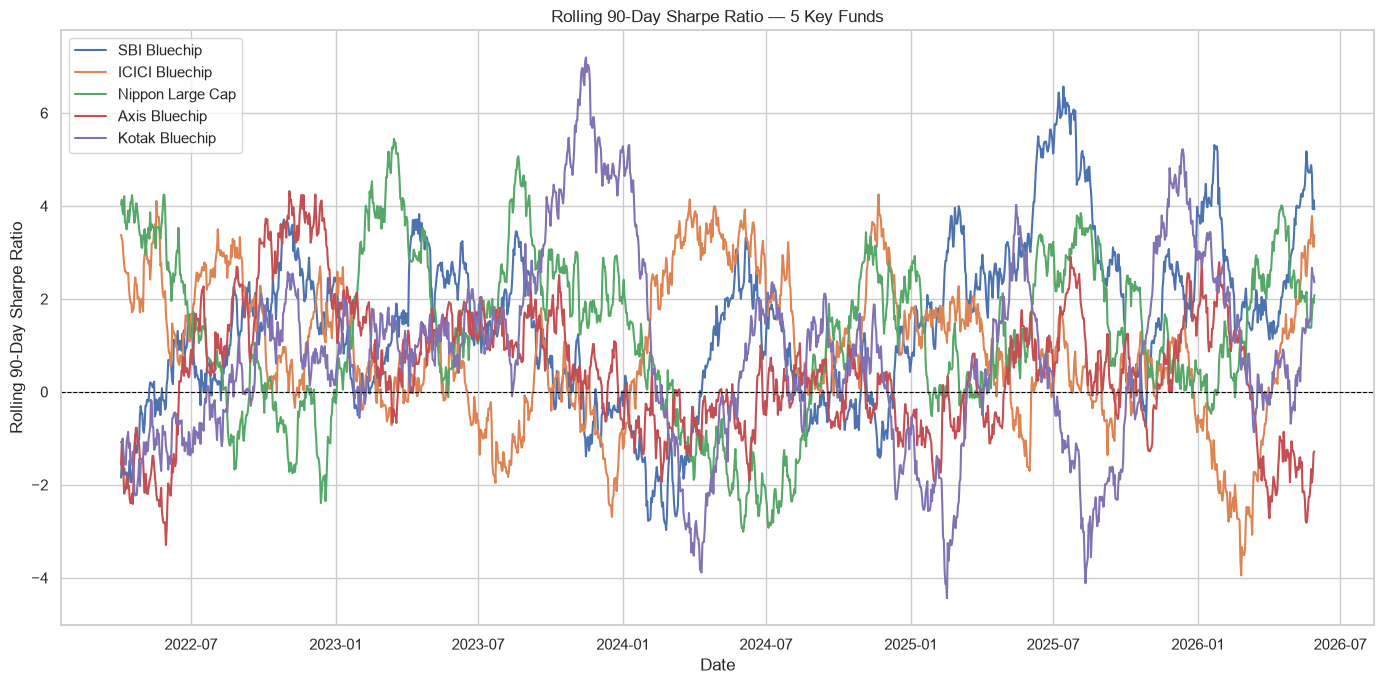

Saved rolling_sharpe_chart.png


In [3]:
KEY_SCHEME_CODES = {
    119551: "SBI Bluechip",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip",
}

# Fall back to first 5 available codes if any key code isn't present in this dataset
available_key_codes = {c: n for c, n in KEY_SCHEME_CODES.items() if c in daily_returns.columns}
if len(available_key_codes) < 5:
    print(f"Note: only {len(available_key_codes)} of the 5 key scheme codes found in nav_history. "
          f"Filling remaining slots with the first available funds.")
    fallback_codes = [c for c in daily_returns.columns if c not in available_key_codes][:5 - len(available_key_codes)]
    for c in fallback_codes:
        name = fund_master.loc[fund_master["amfi_code"] == c, "scheme_name"]
        available_key_codes[c] = name.values[0] if len(name) else str(c)

plt.figure(figsize=(14, 7))
for code, name in available_key_codes.items():
    r = daily_returns[code]
    rolling_sharpe = (r.rolling(90).mean() / r.rolling(90).std()) * np.sqrt(TRADING_DAYS)
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=name)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/rolling_sharpe_chart.png", dpi=150)
plt.savefig("rolling_sharpe_chart.png", dpi=150)  # also save to project root as the named deliverable
plt.show()
print("Saved rolling_sharpe_chart.png")


## Task 3 — Investor Cohort Analysis

Group investors by the year of their first transaction. For each cohort: average SIP amount,
total invested, and top fund preference.

In [4]:
first_txn = investor_transactions.groupby("investor_id")["transaction_date"].min().rename("first_txn_date")
investor_transactions_c = investor_transactions.merge(first_txn, on="investor_id", how="left")
investor_transactions_c["cohort_year"] = investor_transactions_c["first_txn_date"].dt.year

sip_only = investor_transactions_c[investor_transactions_c["transaction_type"] == "SIP"]
avg_sip_by_cohort = sip_only.groupby("cohort_year")["amount_inr"].mean().rename("avg_sip_amount")
total_invested_by_cohort = investor_transactions_c.groupby("cohort_year")["amount_inr"].sum().rename("total_invested")

# Top fund preference per cohort (most frequent amfi_code, mapped to scheme_name)
top_fund_by_cohort = (
    investor_transactions_c.groupby(["cohort_year", "amfi_code"]).size()
    .reset_index(name="txn_count")
    .sort_values(["cohort_year", "txn_count"], ascending=[True, False])
    .groupby("cohort_year").first()[["amfi_code", "txn_count"]]
)
top_fund_by_cohort = top_fund_by_cohort.merge(
    fund_master[["amfi_code", "scheme_name"]], on="amfi_code", how="left"
).rename(columns={"scheme_name": "top_fund_preference"})
top_fund_by_cohort.index = avg_sip_by_cohort.index if len(top_fund_by_cohort) == len(avg_sip_by_cohort) else top_fund_by_cohort.index

cohort_table = pd.concat([avg_sip_by_cohort, total_invested_by_cohort], axis=1).reset_index()
cohort_table = cohort_table.merge(
    top_fund_by_cohort[["top_fund_preference"]].reset_index().rename(columns={"cohort_year": "cohort_year"}),
    left_on="cohort_year", right_on="cohort_year", how="left"
)
cohort_table[["avg_sip_amount", "total_invested"]] = cohort_table[["avg_sip_amount", "total_invested"]].round(2)
cohort_table = cohort_table.sort_values("cohort_year")

cohort_table


,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.89,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.21,30455243,SBI Small Cap Fund - Direct Plan - Growth


## Task 4 — SIP Continuity Analysis

For investors with 6+ SIP transactions, compute the average gap between consecutive SIP dates.
Investors with an average gap greater than 35 days are flagged "at-risk".

In [5]:
sip_txns = investor_transactions[investor_transactions["transaction_type"] == "SIP"].copy()
sip_txns = sip_txns.sort_values(["investor_id", "transaction_date"])

sip_counts = sip_txns.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index

continuity_rows = []
for investor_id, group in sip_txns[sip_txns["investor_id"].isin(eligible_investors)].groupby("investor_id"):
    dates = group["transaction_date"].sort_values()
    gaps = dates.diff().dropna().dt.days
    avg_gap = gaps.mean()
    continuity_rows.append({
        "investor_id": investor_id,
        "sip_count": len(group),
        "avg_gap_days": round(avg_gap, 1),
        "at_risk": avg_gap > 35,
    })

continuity_table = pd.DataFrame(continuity_rows).sort_values("avg_gap_days", ascending=False)

at_risk_count = continuity_table["at_risk"].sum()
total_eligible = len(continuity_table)
print(f"Investors with 6+ SIP transactions: {total_eligible}")
print(f"Flagged as at-risk (avg gap > 35 days): {at_risk_count} ({at_risk_count / total_eligible * 100:.1f}%)")

continuity_table.head(10)


Investors with 6+ SIP transactions: 1362
Flagged as at-risk (avg gap > 35 days): 1332 (97.8%)


,investor_id,sip_count,avg_gap_days,at_risk
506,INV001890,6,102.6,True
323,INV001156,6,102.4,True
1188,INV004296,6,102.2,True
910,INV003325,6,101.0,True
150,INV000522,6,100.8,True
183,INV000608,6,100.2,True
503,INV001883,6,99.2,True
576,INV002166,6,99.2,True
380,INV001367,6,99.0,True
406,INV001491,6,98.8,True


## Task 6 — Sector HHI Concentration

`HHI = sum(weight_i^2)` per fund, using portfolio holdings sector weights. Compared across all
equity funds. Weight_pct is treated as a percentage (0-100), so HHI is computed on the 0-1
fraction scale (standard HHI convention, max value 10,000 if using percentage points directly -
here we use the 0-1 fraction scale where a fully concentrated single-sector fund scores 1.0).

In [6]:
equity_amfi_codes = fund_master[fund_master["category"] == "Equity"]["amfi_code"].unique()

holdings_equity = portfolio_holdings[portfolio_holdings["amfi_code"].isin(equity_amfi_codes)]

sector_weights = holdings_equity.groupby(["amfi_code", "sector"])["weight_pct"].sum().reset_index()
sector_weights["weight_fraction"] = sector_weights["weight_pct"] / 100

hhi_table = (
    sector_weights.groupby("amfi_code")["weight_fraction"]
    .apply(lambda w: (w ** 2).sum())
    .rename("hhi")
    .reset_index()
)
hhi_table = hhi_table.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code", how="left")
hhi_table["hhi"] = hhi_table["hhi"].round(4)
hhi_table = hhi_table.sort_values("hhi", ascending=False)

print("Sector concentration (HHI) across equity funds - higher = more concentrated in fewer sectors:")
hhi_table


Sector concentration (HHI) across equity funds - higher = more concentrated in fewer sectors:


,amfi_code,hhi,scheme_name,fund_house
11,119092,0.2968,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund
30,148569,0.2550,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
27,125498,0.2532,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund
6,102887,0.2514,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund
32,149323,0.2411,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
21,120505,0.2387,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
10,118635,0.2375,Nippon India ETF Nifty 50 BeES,Nippon India MF
18,119599,0.2324,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
22,120506,0.2315,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF
1,100033,0.2276,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund


## Task 7 — 5 Advanced Insights

1. **Highest VaR / Risk (var_cvar_report):** _Small Cap funds carry the most downside risk — ABSL Small Cap Fund has the worst 95% VaR (-2.39%) and CVaR (-3.03%), and all five worst-VaR funds are rated "Very High" risk, confirming the risk labels match actual volatility._
2. **Rolling Sharpe (Chart):** _No fund holds a consistently strong Sharpe ratio — all 5 key funds swing between +6 and -4 at different points, with Kotak Bluechip the most volatile (peaking near 7 in late 2023, dropping below -4 by early 2025). Risk-adjusted performance looks regime-dependent, not a stable trait._
3. **Investor Cohorts:** _The 2024 cohort invested far more in total (~₹3.49B) than 2025 (~₹30M), most likely because 2024 investors have simply had more time to accumulate transactions, not because of a real behavior shift._
4. **SIP Continuity:** _97.8% of eligible investors were flagged "at-risk" (avg gap ~100 days), which likely reflects the dataset's short ~2-year window spreading a fixed number of SIPs out, rather than genuine discontinuation — the 35-day threshold may need adjusting for this dataset._
5. **Sector Concentration (HHI):** _Axis Bluechip is the most concentrated equity fund (HHI 0.297), UTI Mid Cap the most diversified (0.124). No fund is dangerously overexposed to a single sector._
